In [1]:
import os, sys
parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

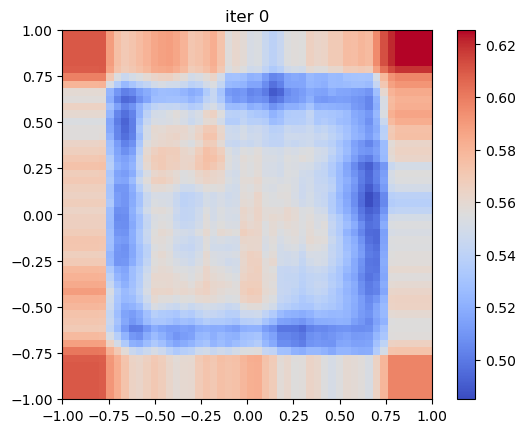

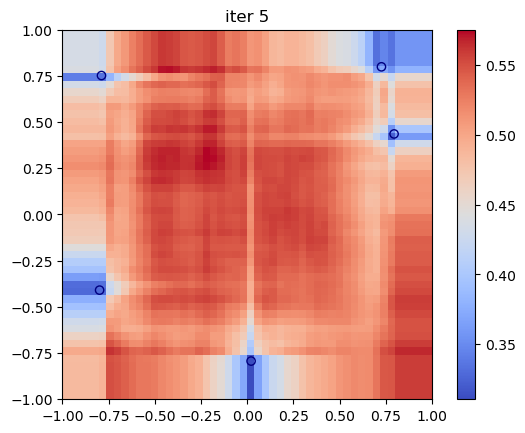

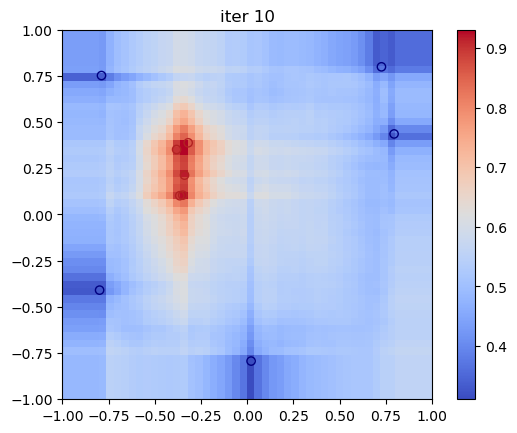

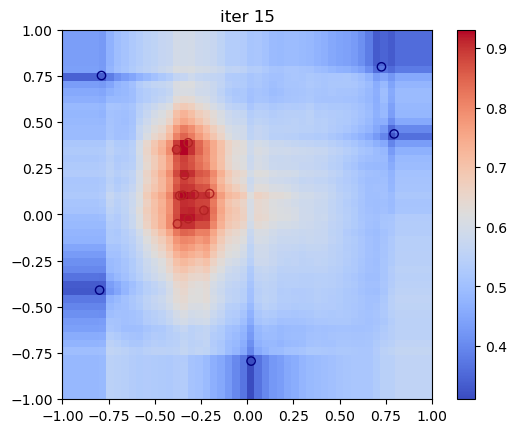

In [2]:
import datasets
from src.alif import Alif
from experiments.utils import run_sim

data, labels = datasets.load()
alif = Alif(parallel_jobs=8)
run_sim(
    model=alif, n_iter=20, data_train=data, labels_train=labels, show_heatmap_evol=True
);

Datasets:   0%|          | 0/14 [00:00<?, ?it/s]

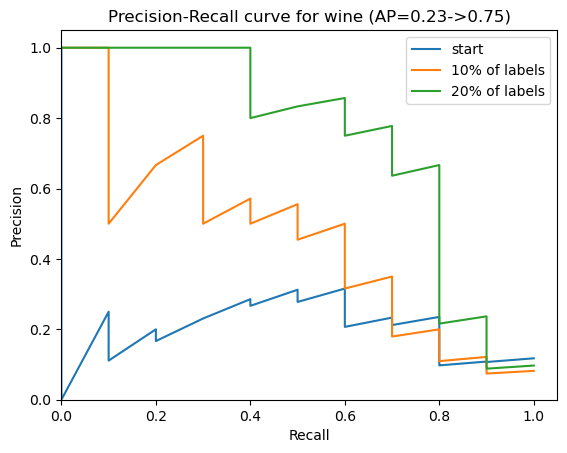

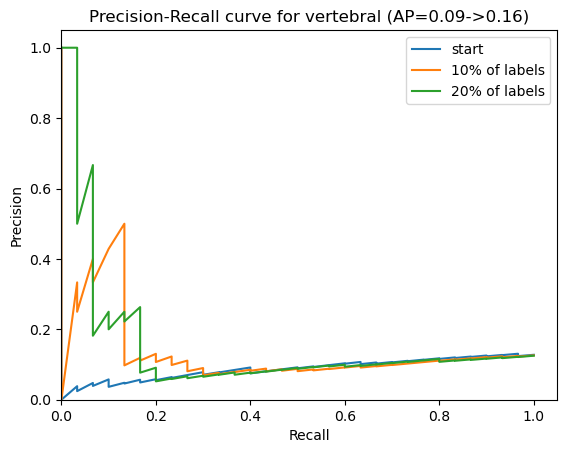

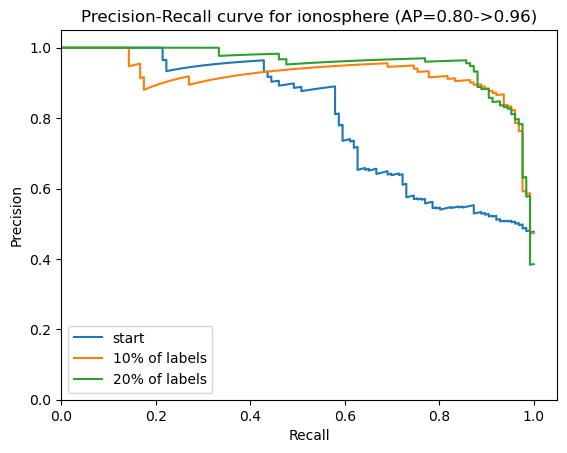

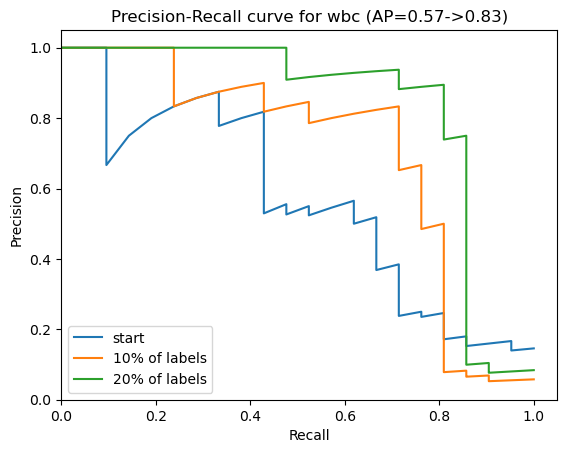

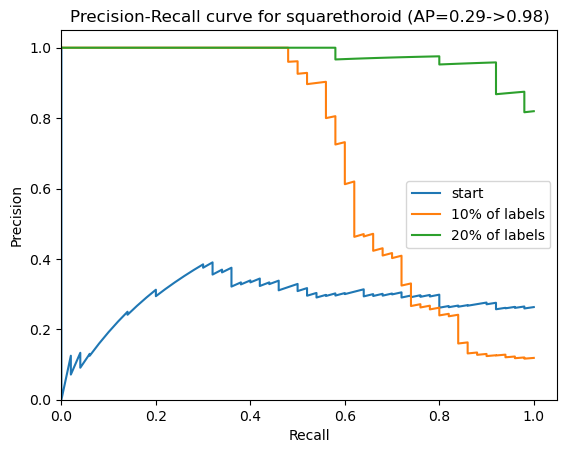

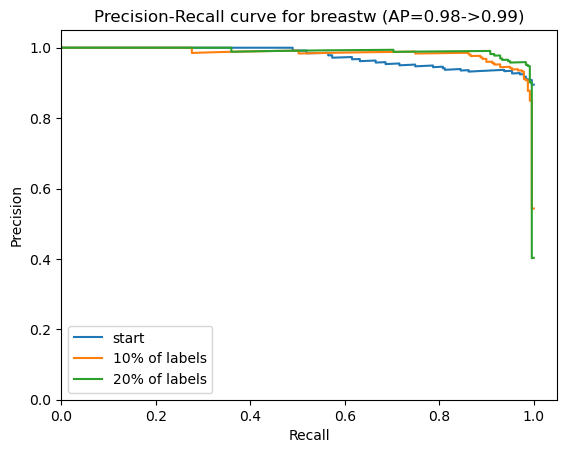

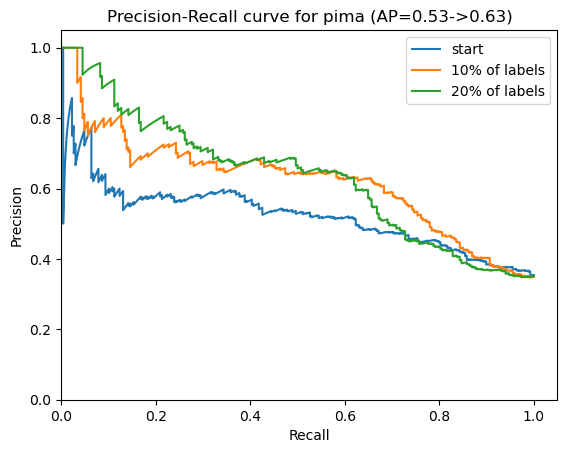

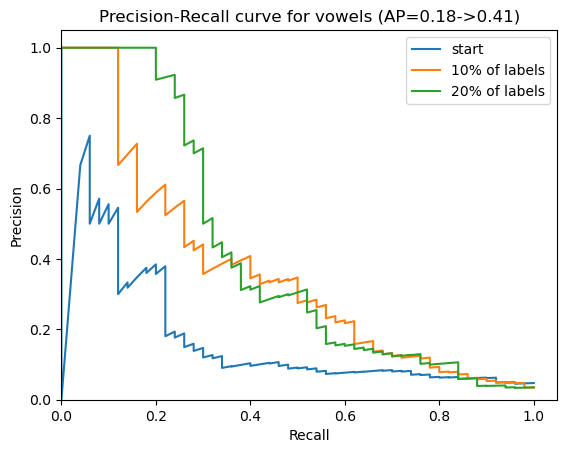

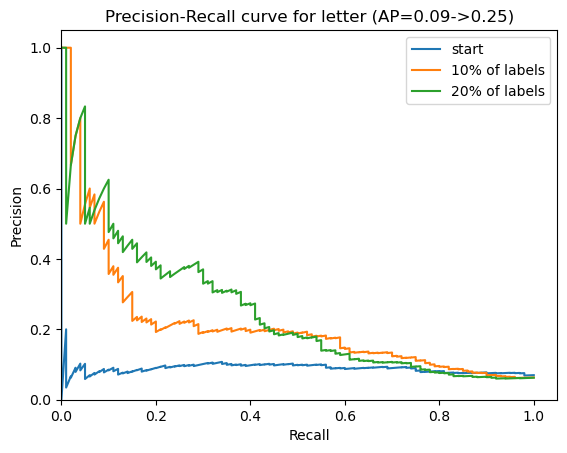

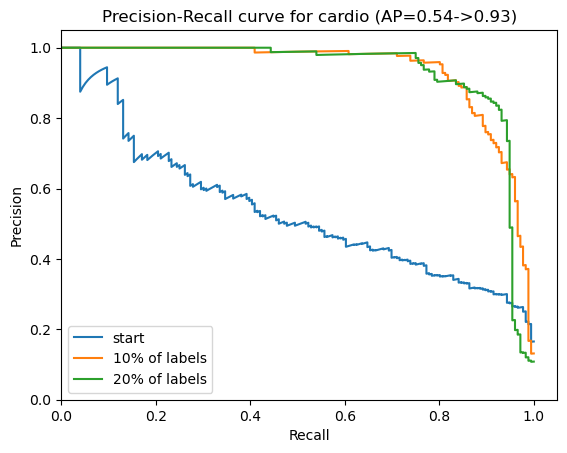

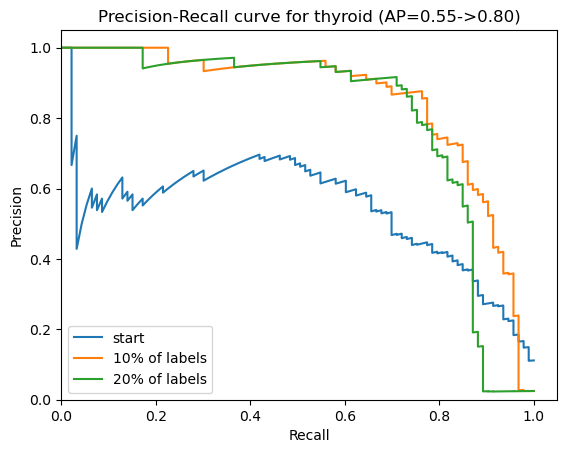

KeyboardInterrupt: 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

import datasets
from src.alif import Alif

from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve

for dataset_name in tqdm(datasets.small_datasets_names, desc="Datasets"):
    data, labels = datasets.load(dataset_name)
    alif = Alif(parallel_jobs=8)
    scores = alif.fit_predict(data)

    precision, recall, _ = precision_recall_curve(labels, scores)
    average_precision = average_precision_score(labels, scores)

    plt.figure()
    plt.plot(recall, precision, label=f"start")
    title = f"Precision-Recall curve for {dataset_name} (AP={average_precision:.2f}->"

    for iter in range(1, 3):
        # sample 10% of the outliers and 10% of the inliers
        outlier_data = data[labels == 1]
        outlier_data = outlier_data[
            np.random.choice(
                outlier_data.shape[0], max((int(outlier_data.shape[0] * 1e-1),1)), replace=False
            )
        ]
        inlier_data = data[labels == 0]
        inlier_data = inlier_data[
            np.random.choice(
                inlier_data.shape[0], max((int(inlier_data.shape[0] * 1e-1),1)), replace=False
            )
        ]
        alif.update(inlier_data=inlier_data, outlier_data=outlier_data)
        scores = alif.predict(data)
        
        precision, recall, _ = precision_recall_curve(labels, scores)
        average_precision = average_precision_score(labels, scores)
        plt.plot(recall, precision, label=f"{iter*10}% of labels")

    title += f"{average_precision:.2f})"
    plt.title(title)
    plt.xlim([0.0, 1.05])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()


In [4]:
import snakeviz
%load_ext snakeviz

import datasets
from src.alif import Alif

data, labels = datasets.load()
alif = Alif()

%snakeviz -t alif.fit(data)

%snakeviz -t alif.predict(data)

The snakeviz extension is already loaded. To reload it, use:
  %reload_ext snakeviz
 
*** Profile stats marshalled to file 'C:\\Users\\dsart\\AppData\\Local\\Temp\\tmp4gpfrf4j'. 
Opening SnakeViz in a new tab...
 
*** Profile stats marshalled to file 'C:\\Users\\dsart\\AppData\\Local\\Temp\\tmpq0iuetu0'. 
Opening SnakeViz in a new tab...
